# Nonlinear Regression

Nonlinear regression is used to model relationships that cannot be adequately described by a straight line. For several common nonlinear models, an appropriate mathematical transformation can convert the original equation into a linear form, allowing the model parameters to be estimated using ordinary least-squares linear regression. This notebook demonstrates this approach using power-law and exponential decay models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Power-Law Regression

In [2]:
def power_law(h, k, alpha):
    return k * h ** alpha

The following example generates synthetic data following a power-law relationship with small random perturbations to simulate measurement noise.

In [3]:
k_true = 1.5
alpha_true = 0.5
h_min = 0.1
h_max = 2

In [4]:
h = np.linspace(h_min, h_max, 20)
noise = np.random.normal(0, 0.02, h.size)
t = power_law(h, k_true, alpha_true) + noise

The scatter plot illustrates the nonlinear relationship between the independent and dependent variables before any transformation is applied.

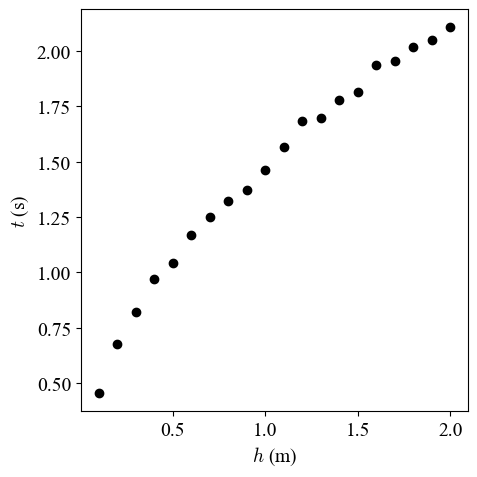

In [5]:
plt.figure(figsize=(5, 5))
plt.scatter(h, t, color="k")
plt.xlabel(r"$h$ (m)")
plt.ylabel(r"$t$ (s)")
plt.tight_layout()
plt.show()

A power-law relationship is expressed as

$$
t=kh^\alpha,
$$

where $k$ is a proportionality constant and $\alpha$ is the power-law exponent. Taking the natural logarithm of both sides gives

$$
\ln{t}=\alpha\ln{h}+\ln{k},
$$

which has the linear form

$$
Y=mX+b,
$$

with

$$
Y=\ln{t},\qquad
X=\ln{h},\qquad
m=\alpha,\qquad
b=\ln{k}.
$$

After estimating the slope and intercept using linear regression, the original model parameters are recovered from

$$
\alpha=m,\qquad
k=e^b.
$$

The following code performs the logarithmic transformation and estimates the model parameters using `scipy.stats.linregress`.

In [6]:
slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(h), np.log(t))

In [7]:
alpha_est = slope
k_est = np.exp(intercept)

In [8]:
print(f"alpha_est: {alpha_est:.3f}")
print(f"k_est: {k_est:.3f}")

alpha_est: 0.505
k_est: 1.493


The fitted power-law model is reconstructed in its original form and evaluated using the coefficient of determination ($R^2$), mean absolute error (MAE), and root mean squared error (RMSE).

In [9]:
t_pred = k_est * h ** alpha_est

In [10]:
r2 = r2_score(t, t_pred)
mae = mean_absolute_error(t, t_pred)
rmse = np.sqrt(mean_squared_error(t, t_pred))

In [11]:
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

R²: 0.998
MAE: 0.017
RMSE: 0.022


The fitted power-law curve is compared with the measured data to assess the agreement between the nonlinear model and the observations.

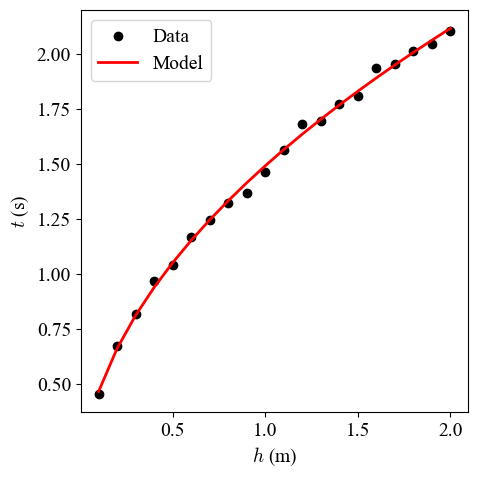

In [12]:
plt.figure(figsize=(5, 5))
plt.scatter(h, t, color="k", label="Data")
plt.plot(h, t_pred, color="r", label="Model", linewidth=2)
plt.xlabel(r"$h$ (m)")
plt.ylabel(r"$t$ (s)")
plt.legend()
plt.tight_layout()
plt.show()

## Exponential Regression

In [13]:
def exponential_decay(t, A, lambda_):
    return A * np.exp(-lambda_ * t)

The following example generates synthetic data representing an exponential decay process with small random perturbations.

In [14]:
A_true = 100
lambda_true = 0.05
t_min = 0
t_max = 50

In [15]:
t = np.linspace(t_min, t_max, 51)
noise = np.random.normal(0, 0.1, t.size)
y = exponential_decay(t, A_true, lambda_true) + noise

The scatter plot illustrates the characteristic exponential decay prior to linearization.

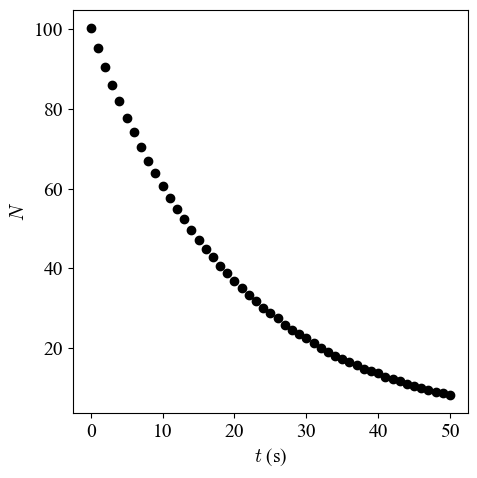

In [16]:
plt.figure(figsize=(5, 5))
plt.scatter(t, y, color="k")
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$N$")
plt.tight_layout()
plt.show()

An exponential decay model is written as

$$
N=Ae^{-\lambda t},
$$

where $A$ is the initial amplitude and $\lambda$ is the decay constant. Applying the natural logarithm yields

$$
\ln{N}=-\lambda t+\ln{A},
$$

which can be rewritten as

$$
Y=mX+b,
$$

with

$$
Y=\ln{N},\qquad
X=t,\qquad
m=-\lambda,\qquad
b=\ln{A}.
$$

The original model parameters are then recovered from

$$
\lambda=-m,\qquad
A=e^b.
$$

The following code estimates these parameters by applying linear regression to the transformed variables.

In [17]:
slope, intercept, r_value, p_value, std_err = stats.linregress(t, np.log(y))

In [18]:
lambda_est = -slope
A_est = np.exp(intercept)

In [19]:
print(f"lambda_est: {lambda_est:.3f}")
print(f"A_est: {A_est:.3f}")

lambda_est: 0.050
A_est: 100.015


The reconstructed exponential model is evaluated using $R^2$, MAE, and RMSE to quantify its predictive performance.

In [20]:
y_pred = A_est * np.exp(-lambda_est * t)

In [21]:
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

In [22]:
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

R²: 1.000
MAE: 0.080
RMSE: 0.099


The fitted exponential curve is compared with the measured data to illustrate the quality of the nonlinear regression.

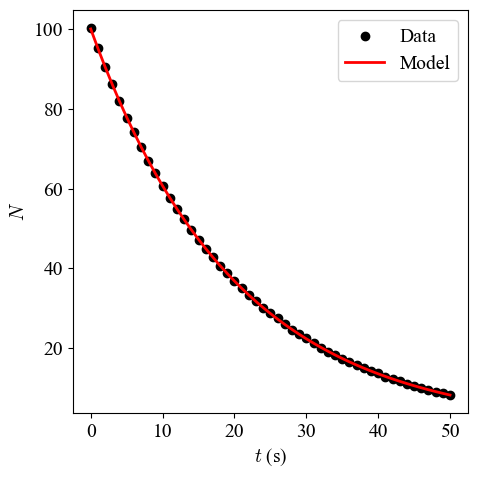

In [23]:
plt.figure(figsize=(5, 5))
plt.scatter(t, y, color="k", label="Data")
plt.plot(t, y_pred, color="r", label="Model", linewidth=2)
plt.xlabel(r"$t$ (s)")
plt.ylabel(r"$N$")
plt.legend()
plt.tight_layout()
plt.show()

## Key Insights

* Many nonlinear relationships can be transformed into linear forms through appropriate mathematical transformations.
* Linearization allows nonlinear model parameters to be estimated using ordinary least-squares linear regression.
* The estimated slope and intercept of the transformed model can be converted back to the original physical parameters.